# Deposition parameter analysis

This notebook compares film-thickness statistics as Si2H6 flow changes while the other listed recipe settings remain fixed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

conditions = pd.read_csv('../data/deposition_condition_summary.csv')
wafer = pd.read_csv('../data/wafer_uniformity_sample.csv')
conditions.head()

,recipe,si2h6_flow,power,temperature,time_sec,average_thickness,min_thickness,max_thickness,range,standard_deviation
0,FT0524_run18,155,300,400,40,2721.9898,2242.1940,3101.1808,858.9867,266.9546
1,FT0524_run17,165,300,400,40,2894.5714,2439.3160,3252.9310,813.6150,255.7452
2,FT0524_run14,175,300,400,30,2238.6181,1904.2499,2488.5010,584.2510,171.2530
3,FT0524_run13,175,400,400,30,2988.3739,2570.5000,3309.9800,739.4800,228.1013
4,FT0524_run15,175,300,400,35,2613.7812,2237.9254,2924.6759,686.7505,204.8853


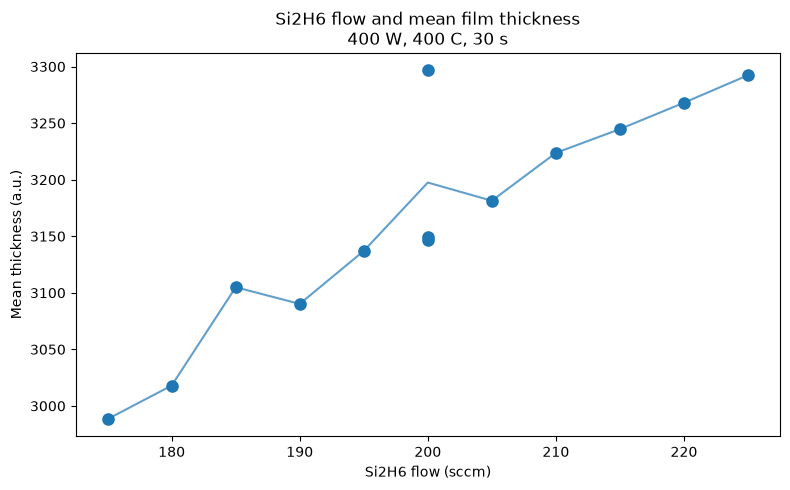

In [2]:
ordered = conditions.sort_values('si2h6_flow')
comparable = ordered[(ordered['power'] == 400) & (ordered['temperature'] == 400) & (ordered['time_sec'] == 30) & ~ordered['recipe'].str.contains('Pre')]
trend = comparable.groupby('si2h6_flow', as_index=False)['average_thickness'].mean()
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(comparable['si2h6_flow'], comparable['average_thickness'], s=65)
ax.plot(trend['si2h6_flow'], trend['average_thickness'], alpha=.7)
ax.set(title='Si2H6 flow and mean film thickness\n400 W, 400 C, 30 s', xlabel='Si2H6 flow (sccm)', ylabel='Mean thickness (a.u.)')
fig.tight_layout()
fig.savefig('../images/gas_flow_vs_thickness.png', dpi=180, bbox_inches='tight')
plt.show()

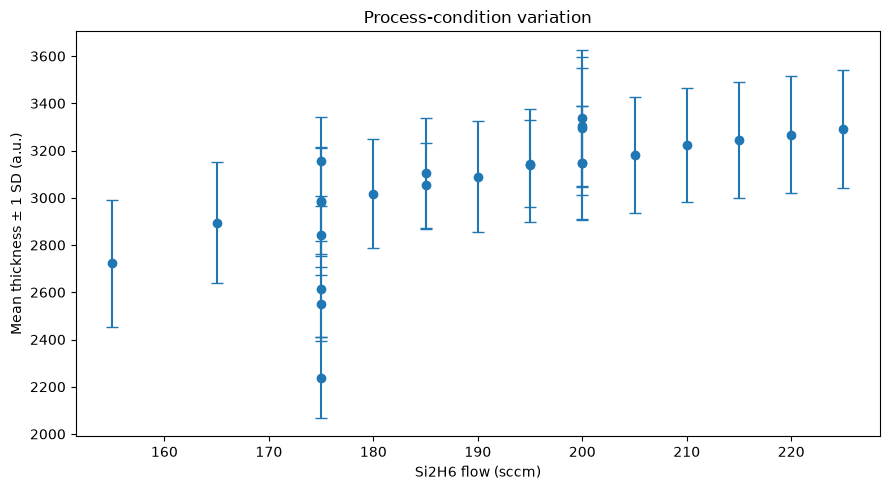

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
ax.errorbar(ordered['si2h6_flow'], ordered['average_thickness'], yerr=ordered['standard_deviation'], fmt='o', capsize=4)
ax.set(title='Process-condition variation', xlabel='Si2H6 flow (sccm)', ylabel='Mean thickness ± 1 SD (a.u.)')
fig.tight_layout()
fig.savefig('../images/process_condition_variation.png', dpi=180, bbox_inches='tight')
plt.show()

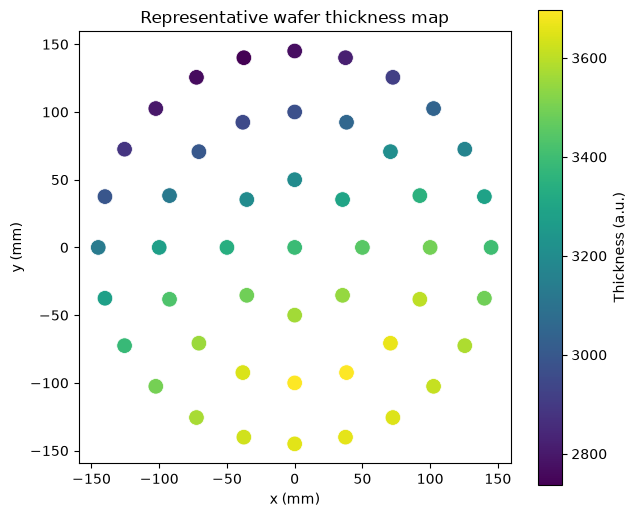

In [4]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
points = ax.scatter(wafer['x_mm'], wafer['y_mm'], c=wafer['thickness'], s=125, cmap='viridis', edgecolor='white', linewidth=.5)
fig.colorbar(points, ax=ax, label='Thickness (a.u.)')
ax.set_aspect('equal')
ax.set(title='Representative wafer thickness map', xlabel='x (mm)', ylabel='y (mm)')
fig.tight_layout()
fig.savefig('../images/wafer_uniformity_map.png', dpi=180, bbox_inches='tight')
plt.show()

## Interpretation and limits

The plots show association, not proof of causality. Results come from an educational dataset and should be interpreted as a structured comparison of recipe conditions. Production decisions would require repeat runs, measurement-system checks, and confirmed specification limits.